# CIS5800 HW4

In this homework you will compute image gradient, optical flow and epipole points.
- You should only modify the `compute grad.py`, `compute flow.py`, and `epipole.py`.
- You only need to submit the above files. 
- Use this notebook to debug and correct your implementation. 

Please follow the attached pdf for further implementation instructions.

## 0. Load Video and Generate Frames via TorchVision

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import torchvision.transforms as T


plt.rcParams["savefig.bbox"] = "tight"
# sphinx_gallery_thumbnail_number = 2

# Plot a set of images
def plot(imgs, **imshow_kwargs):
    # Edge case when only 1 image: Make a 2d grid even if there's just 1 row
    if not isinstance(imgs[0], list):
        imgs = [imgs]

    # Set up Grid
    num_rows = len(imgs)
    num_cols = len(imgs[0])
    _, axs = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 6),  squeeze=False)

    # Plot each image
    for row_idx, row in enumerate(imgs):
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            img = F.to_pil_image(img.to("cpu"))
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

            frame_id = 150 + col_idx
            ax.set_title(f"Frame {frame_id}")

    plt.tight_layout()

In [2]:
import tempfile
from pathlib import Path
from urllib.request import urlretrieve

# Fetch Video
video_url = "https://download.pytorch.org/tutorial/pexelscom_pavel_danilyuk_basketball_hd.mp4"
video_path = Path(tempfile.mkdtemp()) / "basketball.mp4"
_ = urlretrieve(video_url, video_path)

In [3]:
import sys
!{sys.executable} -m pip install av

/opt/anaconda3/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/torchvision/io/video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


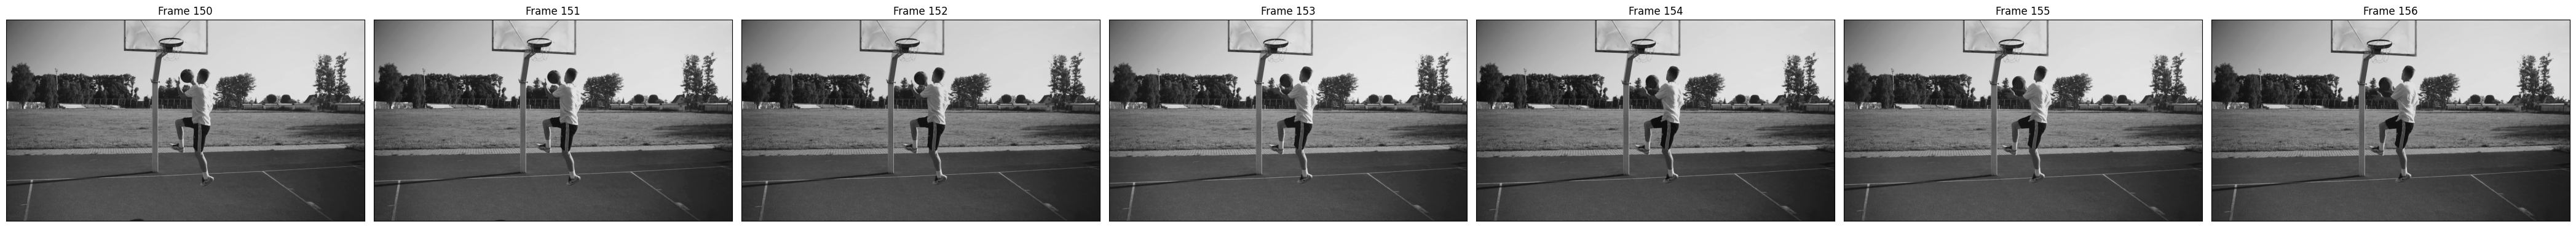

In [4]:
from torchvision.io import read_video
import torchvision.transforms.functional as F

# Read Video into Frames
frames, _, _ = read_video(str(video_path))

# Convert to (N, C, H, W)
frames = frames.permute(0, 3, 1, 2)

# Convert to grayscale (For LK Optical flow! )
img1 = F.rgb_to_grayscale(frames[100]).float() / 255.0
img2 = F.rgb_to_grayscale(frames[101]).float() / 255.0
img3 = F.rgb_to_grayscale(frames[102]).float() / 255.0
img4 = F.rgb_to_grayscale(frames[103]).float() / 255.0
img5 = F.rgb_to_grayscale(frames[104]).float() / 255.0
img6 = F.rgb_to_grayscale(frames[105]).float() / 255.0
img7 = F.rgb_to_grayscale(frames[106]).float() / 255.0

plot([img1, img2, img3, img4, img5, img6, img7], cmap = "gray")

In [5]:
img1 = img1.squeeze(0).numpy()
img2 = img2.squeeze(0).numpy()
img3 = img3.squeeze(0).numpy()
img4 = img4.squeeze(0).numpy()
img5 = img5.squeeze(0).numpy()
img6 = img6.squeeze(0).numpy()
img7 = img7.squeeze(0).numpy()

img1.shape, img2.shape, img3.shape, img4.shape, img5.shape, img6.shape, img7.shape

((720, 1280),
 (720, 1280),
 (720, 1280),
 (720, 1280),
 (720, 1280),
 (720, 1280),
 (720, 1280))

# 1. Compute Image Gradient and Optical Flow

In [ ]:
from compute_grad import compute_Ix, compute_Iy, compute_It
import pickle

# load images
images = np.stack([img1, img2, img3, img4, img5, img6, img7], axis=-1)
print(f'Loaded images with shape: {images.shape}')

# find gradients
Ix = compute_Ix(images)
Iy = compute_Iy(images)
It = compute_It(images)

print(f'Computed gradients with shape: {Ix.shape}, {Iy.shape}, {It.shape}')

Loaded images with shape: (720, 1280, 7)
Computed gradients with shape: (720, 1280, 7), (720, 1280, 7), (720, 1280, 7)
Saved images, Ix, Iy, and It to 'test_data.pkl'.


## 2. Compute Optical Flow

In [ ]:
from compute_flow import flow_lk

# only take the image in the middle for flow computations
valid_idx = 3
flow, confidence = flow_lk(Ix[..., valid_idx], Iy[..., valid_idx], It[..., valid_idx])
    
print(f'Computed LK flow with shape: {flow.shape}, {confidence.shape}')

Computed LK flow with shape: (720, 1280, 2), (720, 1280)


## 3. Visualize Optical Flow

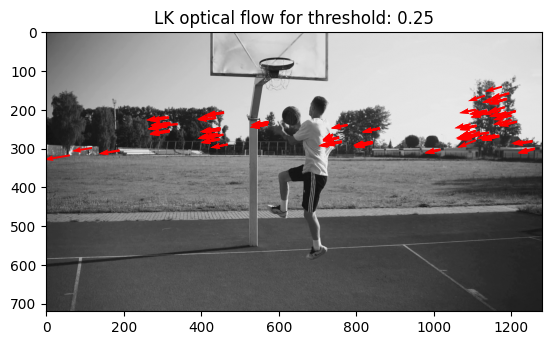

In [8]:
from vis_flow import plot_flow

# TODO: Edit this parameter to see different results.
threshmin = 0.25


# visualize flow
plt.figure()
plot_flow(images[..., valid_idx], flow, confidence, threshmin=threshmin)
plt.title(f'LK optical flow for threshold: {threshmin}')
plt.savefig(f"flow_{threshmin}.png")
plt.show()
plt.cla()
plt.clf()
plt.close()

## 4. Compute Epipole Points

If you have computed this correctly, your result should match `example_epipole_0.25.png`

Computing epipole - this may take a while...
EPIPOLE:  [ 1.91245642e+03 -4.69352042e+02  1.00000000e+00]


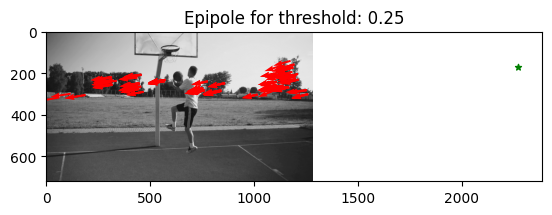

In [9]:
from epipole import epipole

# TODO: Edit this parameter to see different results.
# compute and visualize epipole
print('Computing epipole - this may take a while...')


ep = epipole(flow[..., 0], flow[..., 1], confidence, threshmin, num_iterations=1000)
ep = ep / ep[2]
print("EPIPOLE: ", ep)

# visualize flow and epipole

plt.figure()
plot_flow(images[..., valid_idx], flow, confidence, threshmin=threshmin)

# x = right, y = down
plt.scatter(ep[0] + flow.shape[0]//2, ep[1] + flow.shape[1]//2, c='g', s=20, marker='*')

plt.title(f'Epipole for threshold: {threshmin}')
plt.savefig(f"epipole_{threshmin}.png")
plt.show()